In [1]:
from datetime import datetime
import pandas as pd
import yfinance as yf
import requests
import zipfile
from io import BytesIO
import numpy as np
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [34]:
# ============================
# 1. Windowing Function
# ============================

def create_windows(df_scaled, df_original, target_col="brent_ret_5d", seq_len=30):
    """
    df_scaled  : 입력 피처들 (scaling된 데이터)
    df_original: 원본 데이터 (close값 + 원본 return 포함)
    target_col : 예측할 컬럼 (return)
    """
    X, y, close_today = [], [], []

    scaled_vals = df_scaled.values
    cols = df_scaled.columns.tolist()

    # 가격 복원용 close는 원본 사용
    original_close = df_original["brent_close"].values
    original_target = df_original[target_col].values   # ★ 원본 return 가져오기

    for i in range(len(df_scaled) - seq_len - 1):

        # 입력 시퀀스 (scaled)
        X.append(scaled_vals[i:i+seq_len])

        # target은 scaled 사용하면 절대 안됨!
        y.append(original_target[i+seq_len])

        # price 복원용 원본 close
        close_today.append(original_close[i+seq_len])

    return np.array(X), np.array(y), np.array(close_today)


# ============================
# 2. Dataset + Dataloader
# ============================

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================
# 3. Bi-GRU Model
# ============================

class BiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)  # BiGRU -> 2 * hidden

    def forward(self, x):
        out, _ = self.gru(x)          # out: (batch, seq_len, hidden*2)
        last = out[:, -1, :]          # 마지막 시점
        return self.fc(last)


# ============================
# 4. Train Function
# ============================

def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                pred = model(X_val)
                loss = criterion(pred, y_val)
                val_loss += loss.item()

        print(f"[Epoch {epoch:02d}] train={train_loss:.5f}, val={val_loss:.5f}")


# ============================
# 5. Predict & Price Restoration
# ============================

def predict_and_restore_price(model, X, close_today):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pred_ret = model(X_tensor).numpy().reshape(-1)

    # price 복원
    pred_price = close_today * (1 + pred_ret)
    return pred_ret, pred_price


# ============================
# 6. 시각화
# ============================


def plot_results(y_test, pred_ret, close_test, pred_price):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- Return 시각화 ---
    axes[0].plot(y_test, label="Actual Return", linewidth=2)
    axes[0].plot(pred_ret, label="Predicted Return", linewidth=2)
    axes[0].set_title("Brent 1D Return Prediction")
    axes[0].legend()
    axes[0].grid(True)

    # --- Price 시각화 ---
    axes[1].plot(close_test, label="Actual Close Price", linewidth=2)
    axes[1].plot(pred_price, label="Predicted Close Price", linewidth=2)
    axes[1].set_title("Brent Close Price (Restored from Return)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # 방향성 정확도
    direction = np.mean(np.sign(y_true) == np.sign(y_pred))

    print("\n===== Evaluation =====")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"Direction Accuracy: {direction:.4f}")

    return rmse, mae, direction

def evaluate_price_predictions(true_price, pred_price):
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    mae  = mean_absolute_error(true_price, pred_price)

    # 가격 방향성 (오늘 close 와 내일 close 비교)
    direction = np.mean(np.sign(np.diff(true_price)) == np.sign(np.diff(pred_price)))

    print("\n===== Price Evaluation =====")
    print(f"Price RMSE: {rmse:.6f}")
    print(f"Price MAE : {mae:.6f}")
    print(f"Price Direction Accuracy: {direction:.4f}")

    return rmse, mae, direction

# ============================
# 7. Full Pipeline
# ============================

def run_bigru_pipeline(df, seq_len=30, target_col="brent_ret_5d"):

    # return 컬럼 전체 제거 (leakage 방지)
    ret_cols = [c for c in df.columns if "ret_" in c and c != target_col]

    df_input = df.drop(columns=ret_cols + ["brent_close", "wti_close"], errors="ignore")


    # 2) 스케일링 (input only)
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_input),
        index=df.index,
        columns=df_input.columns
    )

    # 3) window 생성 (y는 원본 return, close_today도 원본)
    X, y, close_today = create_windows(
        df_scaled,
        df_original=df,
        target_col=target_col,
        seq_len=seq_len
    )

    # ----- split -----
    train_size = int(len(X) * 0.7)
    val_size   = int(len(X) * 0.15)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val     = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test   = X[train_size+val_size:], y[train_size+val_size:]
    close_test       = close_today[train_size+val_size:]

    # ----- dataloader -----
    train_ds = TimeSeriesDataset(X_train, y_train)
    val_ds   = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32)

    # ----- model -----
    input_dim = X.shape[2]
    #model = BiGRU(input_dim=input_dim, hidden_dim=64, num_layers=1)
    model = BiGRU(input_dim=input_dim, hidden_dim=256, num_layers=3, dropout=0.3)

    # ----- train -----
    train_model(model, train_loader, val_loader, epochs=40, lr=1e-3)

    # ----- test prediction -----
    pred_ret, pred_price = predict_and_restore_price(model, X_test, close_test)

    # ----- evaluation -----
    rmse, mae, direction = evaluate_predictions(y_test, pred_ret)

    # ----- price evaluation -----
    price_rmse, price_mae, price_dir = evaluate_price_predictions(close_test, pred_price)
    import joblib

    # ----- plot -----
    plot_results(y_test, pred_ret, close_test, pred_price)
    torch.save(model.state_dict(), "../ai/model_weight/bigru_brent_ret5d.pth")
    joblib.dump(scaler, "../ai/model_weight/scaler_brent_ret5d.pkl")

    return {
        "model": model,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "direction_accuracy": direction,
            "price_rmse": price_rmse,
            "price_mae": price_mae,
            "price_direction": price_dir,
        },
        "prediction": {
            "y_test": y_test,
            "pred_ret": pred_ret,
            "pred_price": pred_price
        },
        "scaler": scaler,
        "train_windows": X_train,     
         "feature_names": df_input.columns.tolist()
    }


In [6]:
def make_brent_wti_features(start="2013-09-01", end=None, target_horizon=1):
    import yfinance as yf
    import pandas as pd

    brent = yf.download("BZ=F", start=start, end=end, auto_adjust=False, progress=False)
    wti   = yf.download("CL=F", start=start, end=end, auto_adjust=False, progress=False)

    brent = brent.rename(columns=str.lower)
    wti   = wti.rename(columns=str.lower)

    df = pd.DataFrame(index=brent.index)
    df["brent_close"] = brent["close"]
    df["wti_close"]   = wti["close"].reindex(df.index)

    # Spread
    df["brent_wti_spread"] = df["brent_close"] - df["wti_close"]

    # Returns (미래 정보 포함 가능성 있음 → 뒤에서 필터링)
    df["brent_ret_1d"]  = df["brent_close"].pct_change(1)
    df["brent_ret_5d"]  = df["brent_close"].pct_change(5)
    df["brent_ret_20d"] = df["brent_close"].pct_change(20)

    df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
    df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
    df["wti_ret_20d"] = df["wti_close"].pct_change(20)

    # Moving averages
    df["brent_ma_5"]  = df["brent_close"].rolling(5).mean()
    df["brent_ma_20"] = df["brent_close"].rolling(20).mean()
    df["brent_ma_60"] = df["brent_close"].rolling(60).mean()

    df["wti_ma_5"]  = df["wti_close"].rolling(5).mean()
    df["wti_ma_20"] = df["wti_close"].rolling(20).mean()
    df["wti_ma_60"] = df["wti_close"].rolling(60).mean()

    # Volatility proxies
    df["brent_vol_5d"] = df["brent_close"].pct_change().rolling(5).std()
    df["wti_vol_5d"]   = df["wti_close"].pct_change().rolling(5).std()

    df["high_low_range"] = (brent["high"] - brent["low"]) / brent["close"]

    if target_horizon == 1:
        # 1D 예측은 안전 → 그대로 두기
        pass

    elif target_horizon == 5:
        # 5D 예측 → 어떤 5D/20D return feature도 남아 있으면 안 됨
        drop_cols = [
            c for c in df.columns
            if (
                ("ret_5d" in c or "ret_20d" in c)
                and c != "brent_ret_5d"  # 타겟만 남기기
            )
        ]
        df = df.drop(columns=drop_cols)

    elif target_horizon == 20:
        # 20D 예측 → 5d/20d return 전부 제거 (타겟 제외)
        drop_cols = [
            c for c in df.columns
            if ("ret_5d" in c or "ret_20d" in c)
            and c != "brent_ret_20d"
        ]
        df = df.drop(columns=drop_cols)

    return df.dropna()


features = make_brent_wti_features(target_horizon=5)
features = features[features.index >= "2014-01-01"]
print(features.head())

            brent_close  wti_close  brent_wti_spread  brent_ret_1d  \
Date                                                                 
2014-01-02   107.779999  95.440002         12.339996     -0.027256   
2014-01-03   106.889999  93.959999         12.930000     -0.008258   
2014-01-06   106.730003  93.430000         13.300003     -0.001497   
2014-01-07   107.349998  93.669998         13.680000      0.005809   
2014-01-08   107.150002  92.330002         14.820000     -0.001863   

            brent_ret_5d  wti_ret_1d  brent_ma_5  brent_ma_20  brent_ma_60  \
Date                                                                         
2014-01-02     -0.036819   -0.030278  110.790001     110.6705   109.391334   
2014-01-03     -0.045455   -0.015507  109.772000     110.3840   109.356167   
2014-01-06     -0.048583   -0.005641  108.682001     110.1265   109.310667   
2014-01-07     -0.034709    0.002569  107.910001     109.9450   109.271834   
2014-01-08     -0.032942   -0.014306  107

C:\Users\SKAX\AppData\Local\Temp\ipykernel_11560\3442340089.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_1d"]  = df["wti_close"].pct_change(1)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_11560\3442340089.py:24: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["wti_ret_5d"]  = df["wti_close"].pct_change(5)
C:\Users\SKAX\AppData\Local\Temp\ipykernel_11560\3442340089.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

In [9]:
features.columns


Index(['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d', 'wti_ret_1d', 'brent_ma_5', 'brent_ma_20',
       'brent_ma_60', 'wti_ma_5', 'wti_ma_20', 'wti_ma_60', 'brent_vol_5d',
       'wti_vol_5d', 'high_low_range'],
      dtype='object')

In [ ]:
# df=pd.read_csv('brent_minimal_structured_plus_unstructured.csv')
# df.columns

Index(['brent_close', 'prod_weekly', 'wti_mm_net_long', 'brent_ret_1d',
       'brent_ret_5d', 'brent_ret_20d', 'brent_news_impact_1',
       'brent_news_impact_2', 'brent_news_impact_3', 'brent_news_impact_4',
       'eia_news_impact_1', 'eia_news_impact_2', 'eia_news_impact_3',
       'eia_news_impact_4', 'eia_news_impact_5', 'cot_news_impact_1',
       'cot_news_impact_2', 'cot_news_impact_3'],
      dtype='object')

In [13]:
df=pd.read_csv('../data/classified_clusters_data_final.csv')
df = df.set_index("Date")
df.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore,date,brent_news_impact_1,brent_news_impact_2,brent_news_impact_3,brent_news_impact_4,eia_news_impact_1,eia_news_impact_2,eia_news_impact_3,eia_news_impact_4,eia_news_impact_5,cot_news_impact_1,cot_news_impact_2,cot_news_impact_3
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728363,85.919952,27.177942,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-7.200000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,NaN,NaN,1,NaN,2014-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523983,85.713120,27.133377,0.001984,-0.003667,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-3.640000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,Normal,0.0,0,-0.621995,2014-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.046031,108.682001,110.1265,109.310667,0.010182,0.012836,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.650002,55.600620,85.692421,27.031519,-0.001733,0.001380,-0.000241,-0.003754,2.98,0.40,2.58,1951.0,1951.0,1951.0,1951.0,-4.170000e-12,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,High,1,1,NaN,Normal,0.0,0,-0.621995,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-07,107.349998,93.669998,13.680000,0.00580

In [15]:
columns=['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d', 'wti_ret_1d', 'brent_ma_5', 'brent_ma_20',
       'brent_ma_60', 'wti_ma_5', 'wti_ma_20', 'wti_ma_60', 'brent_vol_5d',
       'wti_vol_5d', 'high_low_range', 'brent_news_impact_1',
       'brent_news_impact_2', 'brent_news_impact_3', 'brent_news_impact_4',
       'eia_news_impact_1', 'eia_news_impact_2', 'eia_news_impact_3',
       'eia_news_impact_4', 'eia_news_impact_5', 'cot_news_impact_1',
       'cot_news_impact_2', 'cot_news_impact_3']

In [20]:
# 1) 둘 다 인덱스를 datetime으로 통일 + 시간은 00:00:00으로 normalize
features = features.copy()
df = df.copy()

features.index = pd.to_datetime(features.index).normalize()
df.index       = pd.to_datetime(df.index).normalize()

# 2) Date(index) 기준으로 join
merged = features.join(df, how="left", rsuffix="_df")


merged.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,wti_ret_1d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,brent_close_df,wti_close_df,brent_wti_spread_df,brent_ret_1d_df,brent_ret_5d_df,brent_ret_20d,brent_ma_5_df,brent_ma_20_df,brent_ma_60_df,brent_vol_5d_df,high_low_range_df,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore,date,brent_news_impact_1,brent_news_impact_2,brent_news_impact_3,brent_news_impact_4,eia_news_impact_1,eia_news_impact_2,eia_news_impact_3,eia_news_impact_4,eia_news_impact_5,cot_news_impact_1,cot_news_impact_2,cot_news_impact_3
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.030278,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.032930,110.790001,110.6705,109.391334,0.011831,0.033680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.629997,55.728363,85.919952,27.177942,NaN,NaN,NaN,NaN,3.00,0.39,2.61,2113.0,2113.0,2113.0,2113.0,-7.200000e-12,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,High,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2014-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.015507,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.050879,109.772000,110.3840,109.356167,0.010935,0.017214,326737.0,226959.0,226959.0,-3958.0,6243.0,6243.0,-0.025439,0.048841,0.048841,8145.0,8108.75,0.002955,58.0,7961.0,7680.75,7903.0,92.3,NaN,NaN,NaN,NaN,NaN,80.790001,55.523983,85.713120,27.133377,0.001984,-0.003667,-0.002407,-0.001640,3.01,0.41,2.60,2036.0,2036.0,2036.0,2036.0,-3.640000e-12,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,High,1.0,1.0,NaN,Normal,0.0,0.0,-0.621995,2014-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0

In [21]:
merged=merged[columns]
merged.head()

,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,wti_ret_1d,brent_ma_5,brent_ma_20,brent_ma_60,wti_ma_5,wti_ma_20,wti_ma_60,brent_vol_5d,wti_vol_5d,high_low_range,brent_news_impact_1,brent_news_impact_2,brent_news_impact_3,brent_news_impact_4,eia_news_impact_1,eia_news_impact_2,eia_news_impact_3,eia_news_impact_4,eia_news_impact_5,cot_news_impact_1,cot_news_impact_2,cot_news_impact_3
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,107.779999,95.440002,12.339996,-0.027256,-0.036819,-0.030278,110.790001,110.6705,109.391334,98.604001,97.9800,97.413000,0.011831,0.014810,0.033680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-03,106.889999,93.959999,12.930000,-0.008258,-0.045455,-0.015507,109.772000,110.3840,109.356167,97.486000,97.8760,97.257167,0.010935,0.013672,0.017214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-06,106.730003,93.430000,13.300003,-0.001497,-0.048583,-0.005641,108.682001,110.1265,109.310667,96.108000,97.6875,97.083667,0.010182,0.009727,0.012836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-07,107.349998,93.669998,13.680000,0.005809,-0.034709,0.002569,107.910001,109.9450,109.271834,94.984000,97.5020,96.927667,0.012422,0.012333,0.007452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-08,107.150002,92.330002,14.820000,-0.001863,-0.032942,-0.014306,107.180000,109.7220,109.221667,93.766000,97.2360,96.741667,0.012569,0.012272,0.008493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
merged = merged.dropna()

[Epoch 01] train=0.38239, val=0.02312
[Epoch 02] train=0.10243, val=0.02003
[Epoch 03] train=0.08846, val=0.01807
[Epoch 04] train=0.10277, val=0.01805
[Epoch 05] train=0.08498, val=0.02820
[Epoch 06] train=0.07280, val=0.01715
[Epoch 07] train=0.07793, val=0.01990
[Epoch 08] train=0.07868, val=0.02113
[Epoch 09] train=0.07340, val=0.01906
[Epoch 10] train=0.06980, val=0.01816
[Epoch 11] train=0.06809, val=0.01765
[Epoch 12] train=0.07731, val=0.02382
[Epoch 13] train=0.06547, val=0.01920
[Epoch 14] train=0.06866, val=0.02175
[Epoch 15] train=0.06906, val=0.02491
[Epoch 16] train=0.06884, val=0.01973
[Epoch 17] train=0.06248, val=0.02085
[Epoch 18] train=0.05976, val=0.01959
[Epoch 19] train=0.06323, val=0.02016
[Epoch 20] train=0.06254, val=0.02069
[Epoch 21] train=0.05697, val=0.01893
[Epoch 22] train=0.06066, val=0.01888
[Epoch 23] train=0.05596, val=0.02389
[Epoch 24] train=0.05705, val=0.01920
[Epoch 25] train=0.05693, val=0.01929
[Epoch 26] train=0.05689, val=0.02016
[Epoch 27] t

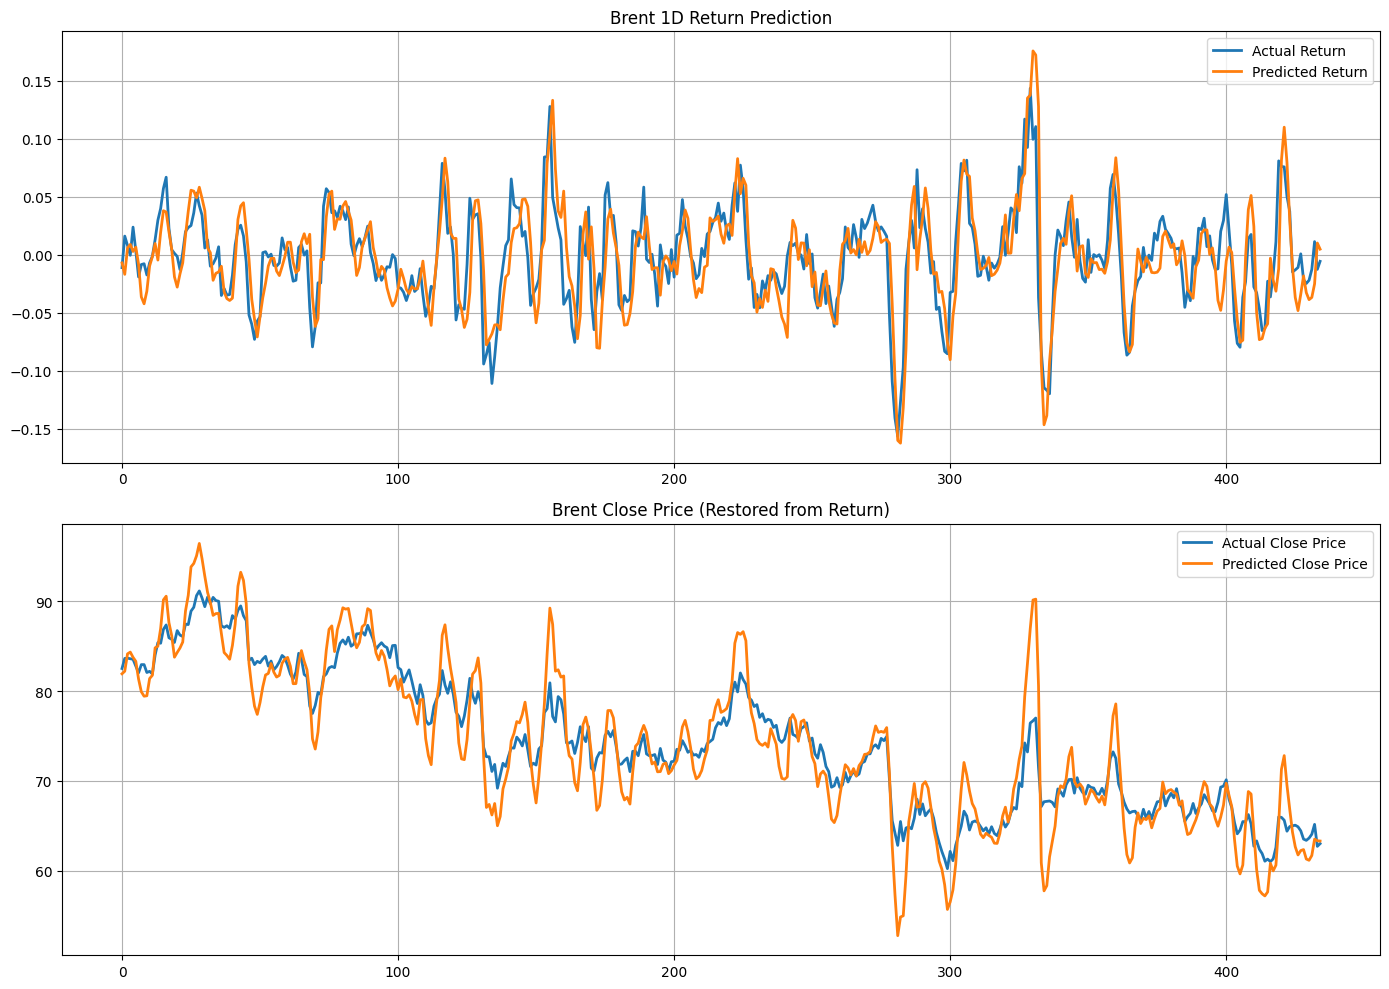

{'model': BiGRU(
   (gru): GRU(23, 256, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
   (fc): Linear(in_features=512, out_features=1, bias=True)
 ),
 'metrics': {'rmse': 0.028605721886634652,
  'mae': 0.02139137017716333,
  'direction_accuracy': 0.7793103448275862,
  'price_rmse': 3.1582534569067717,
  'price_mae': 2.36411432693337,
  'price_direction': 0.7073732718894009},
 'prediction': {'y_test': array([-1.12615602e-02,  1.59097067e-02,  7.82851422e-03, -5.97531056e-04,
          2.36461681e-02,  3.27158944e-03, -1.92468689e-02, -8.60422106e-03,
         -7.89289214e-03, -1.75942689e-02, -7.12565152e-03, -1.46273458e-03,
          1.28977785e-02,  2.96528340e-02,  3.97172811e-02,  5.69273854e-02,
          6.66503809e-02,  2.28489610e-02,  4.21447691e-03,  1.05465164e-03,
         -1.61122558e-03, -1.29319900e-02,  1.62884694e-03,  1.98181931e-02,
          2.32938998e-02,  2.50143881e-02,  3.59420113e-02,  5.29678869e-02,
          4.21810090e-02,  3.38595189e-0

In [35]:
result = run_bigru_pipeline(merged)
result

In [31]:
len(merged)

2926